Original Dataset:
   AnnualIncome  SpendingScore
0          15.0             39
1          15.5             42
2          16.0             45
3          16.5             48
4          17.0             51

Scaled Dataset:
   AnnualIncome  SpendingScore
0     -0.869761      -0.135877
1     -0.838899      -0.033387
2     -0.808036       0.069103
3     -0.777174       0.171594
4     -0.746311       0.274084

Dataset with DBSCAN Cluster Assignments (eps=0.5):
   AnnualIncome  SpendingScore  Cluster
0          15.0             39        0
1          15.5             42        0
2          16.0             45        0
3          16.5             48        0
4          17.0             51        0

Number of clusters found: 2
Number of noise points: 4


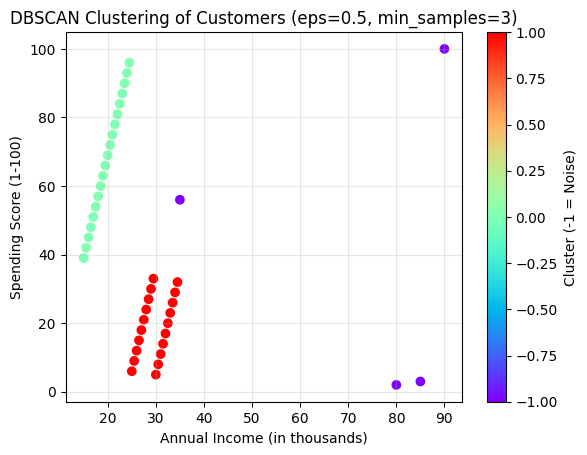


With eps=0.7:
Number of clusters found: 2
Number of noise points: 4


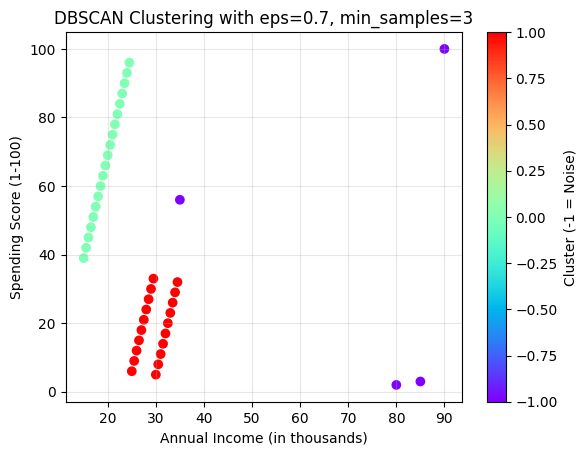

In [1]:
"""
DBSCAN Clustering for Customer Segmentation

This notebook demonstrates DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
on a customer dataset. DBSCAN is particularly effective at identifying outliers and clusters
of arbitrary shapes, unlike k-means which assumes spherical clusters.

Key concepts:
    - eps (epsilon): Maximum distance between two points to be considered neighbors
    - min_samples: Minimum number of points to form a dense region (cluster)
    - Noise points: Points labeled as -1 that don't belong to any cluster

Dependencies:
    - pandas: Data manipulation and analysis
    - matplotlib: Data visualization
    - scikit-learn: DBSCAN algorithm and preprocessing

"""

# Import required libraries
# pandas for data manipulation
# matplotlib for visualization
# DBSCAN for density-based clustering
# StandardScaler for feature normalization
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Create a sample dataset with customer annual income and spending score
# This dataset intentionally includes:
# - 41 normal customer data points with typical income/spending patterns
# - 3 outliers (high income with very low/high spending) to test DBSCAN's outlier detection
data = {'AnnualIncome': [
        15, 15.5, 16, 16.5, 17, 17.5, 18, 18.5, 19, 19.5, 
        20, 20.5, 21, 21.5, 22, 22.5, 23, 23.5, 24, 24.5, 
        25, 25.5, 26, 26.5, 27, 27.5, 28, 28.5, 29, 29.5, 
        30, 30.5, 31, 31.5, 32, 32.5, 33, 33.5, 34, 34.5, 
        35,   # Normal points
        80, 85, 90  # Outliers - high income customers
    ],
    'SpendingScore': [
        39, 42, 45, 48, 51, 54, 57, 60, 63, 66,
        69, 72, 75, 78, 81, 84, 87, 90, 93, 96,
        6, 9, 12, 15, 18, 21, 24, 27, 30, 33,
        5, 8, 11, 14, 17, 20, 23, 26, 29, 32,
        56,   # Normal points
        2, 3, 100  # Outliers - unusual spending patterns
    ]}

# Convert dictionary to DataFrame for easier data manipulation
df = pd.DataFrame(data)

# Display the first few rows of the dataset to understand the data structure
print("Original Dataset:")
print(df.head())

# Normalize the dataset using StandardScaler
# Normalization is crucial for DBSCAN because:
# 1. It uses distance metrics (Euclidean by default)
# 2. Features with larger scales would dominate the distance calculation
# 3. Ensures both features contribute equally to cluster formation
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Convert the scaled data back into a DataFrame for easier handling
# Columns retain original names for interpretability
df_scaled = pd.DataFrame(df_scaled, columns=['AnnualIncome', 'SpendingScore'])
print("\nScaled Dataset:")
print(df_scaled.head())

# Initialize DBSCAN with the parameters
# eps=0.5: Two points are neighbors if their distance is <= 0.5
# min_samples=3: A point needs at least 3 neighbors (including itself) to be a core point
# Note: These parameters may need tuning based on your specific dataset
dbscan = DBSCAN(eps=0.5, min_samples=3)

# Fit the model to the scaled data
# DBSCAN works by:
# 1. Finding core points (points with >= min_samples neighbors within eps)
# 2. Forming clusters by connecting core points
# 3. Assigning border points to clusters
# 4. Marking isolated points as noise (-1)
dbscan.fit(df_scaled)

# Assign cluster labels to the data points
# Labels: -1 = noise/outliers, 0, 1, 2, ... = cluster IDs
df['Cluster'] = dbscan.labels_

# Display the first few rows with cluster labels
print("\nDataset with DBSCAN Cluster Assignments (eps=0.5):")
print(df.head())
print(f"\nNumber of clusters found: {len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)}")
print(f"Number of noise points: {list(dbscan.labels_).count(-1)}")

# Plot the clusters
# Noise points (cluster -1) will appear in a distinct color
# This visualization uses the original (non-scaled) data for interpretability
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['Cluster'], cmap='rainbow')
plt.title('DBSCAN Clustering of Customers (eps=0.5, min_samples=3)')
plt.xlabel('Annual Income (in thousands)')
plt.ylabel('Spending Score (1-100)')
plt.colorbar(label='Cluster (-1 = Noise)')
plt.grid(True, alpha=0.3)
plt.show()

# Experiment: Increase eps to 0.7 to see how it affects clustering
# A larger eps value means:
# - Points further apart can still be neighbors
# - May merge previously separate clusters
# - May reduce the number of noise points
dbscan = DBSCAN(eps=0.7, min_samples=3)
dbscan.fit(df_scaled)
df['Cluster'] = dbscan.labels_

print(f"\nWith eps=0.7:")
print(f"Number of clusters found: {len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)}")
print(f"Number of noise points: {list(dbscan.labels_).count(-1)}")

# Plot the updated clusters with increased eps
# Compare this plot with the previous one to understand the impact of eps
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['Cluster'], cmap='rainbow')
plt.title('DBSCAN Clustering with eps=0.7, min_samples=3')
plt.xlabel('Annual Income (in thousands)')
plt.ylabel('Spending Score (1-100)')
plt.colorbar(label='Cluster (-1 = Noise)')
plt.grid(True, alpha=0.3)
plt.show()